In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os


path = r"C:\Users\JATIN\mutual_fund_project\data\processed"
files = glob.glob(path + "/*.csv")

print("Files found:", len(files))

dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)

all_data = pd.concat(dfs, ignore_index=True)
all_data['date'] = pd.to_datetime(all_data['date'], dayfirst=True, errors='coerce')
all_data['nav'] = pd.to_numeric(all_data['nav'], errors='coerce')

print("Total records:", len(all_data))
print(all_data.head())

Files found: 6
Total records: 19798
        date        nav    scheme_name  scheme_code
0 2026-06-01  6156.7532  Axis_Bluechip       119092
1 2026-05-29  6151.1139  Axis_Bluechip       119092
2 2026-05-27  6146.6118  Axis_Bluechip       119092
3 2026-05-26  6144.0004  Axis_Bluechip       119092
4 2026-05-25  6144.8478  Axis_Bluechip       119092


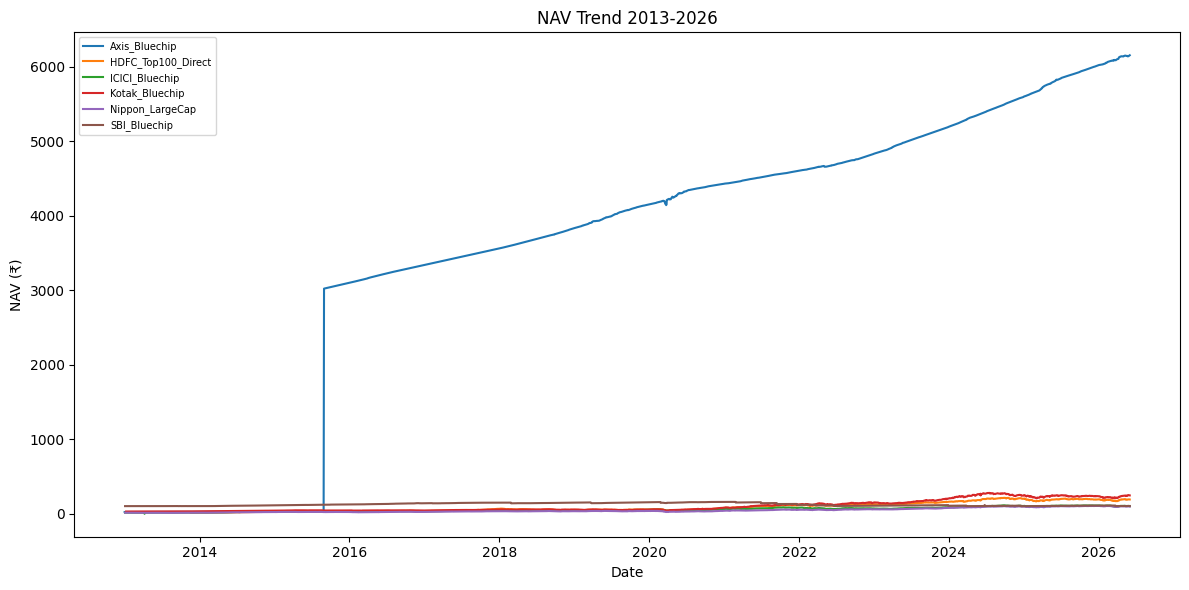

Chart 1 saved!


In [7]:

plt.figure(figsize=(12,6))
for scheme in all_data['scheme_name'].unique():
    df = all_data[all_data['scheme_name'] == scheme]
    df = df.sort_values('date')
    plt.plot(df['date'], df['nav'], label=scheme)

plt.title('NAV Trend 2013-2026')
plt.xlabel('Date')
plt.ylabel('NAV (₹)')
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig(r"C:\Users\JATIN\mutual_fund_project\reports\chart1_nav_trend.png")
plt.show()
print("Chart 1 saved!")

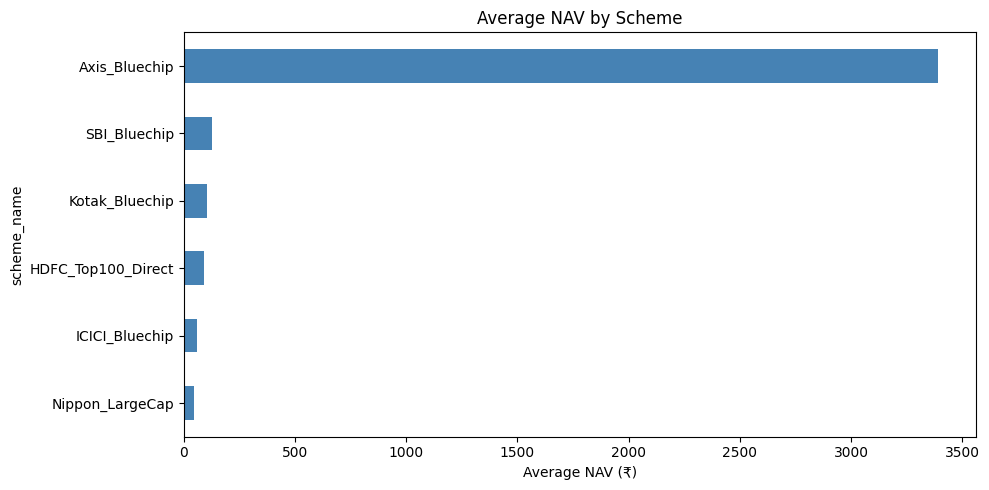

Chart 2 saved!


In [8]:
# Chart 2 - Average NAV per scheme
avg_nav = all_data.groupby('scheme_name')['nav'].mean().sort_values()

plt.figure(figsize=(10,5))
avg_nav.plot(kind='barh', color='steelblue')
plt.title('Average NAV by Scheme')
plt.xlabel('Average NAV (₹)')
plt.tight_layout()
plt.savefig(r"C:\Users\JATIN\mutual_fund_project\reports\chart2_avg_nav.png")
plt.show()
print("Chart 2 saved!")

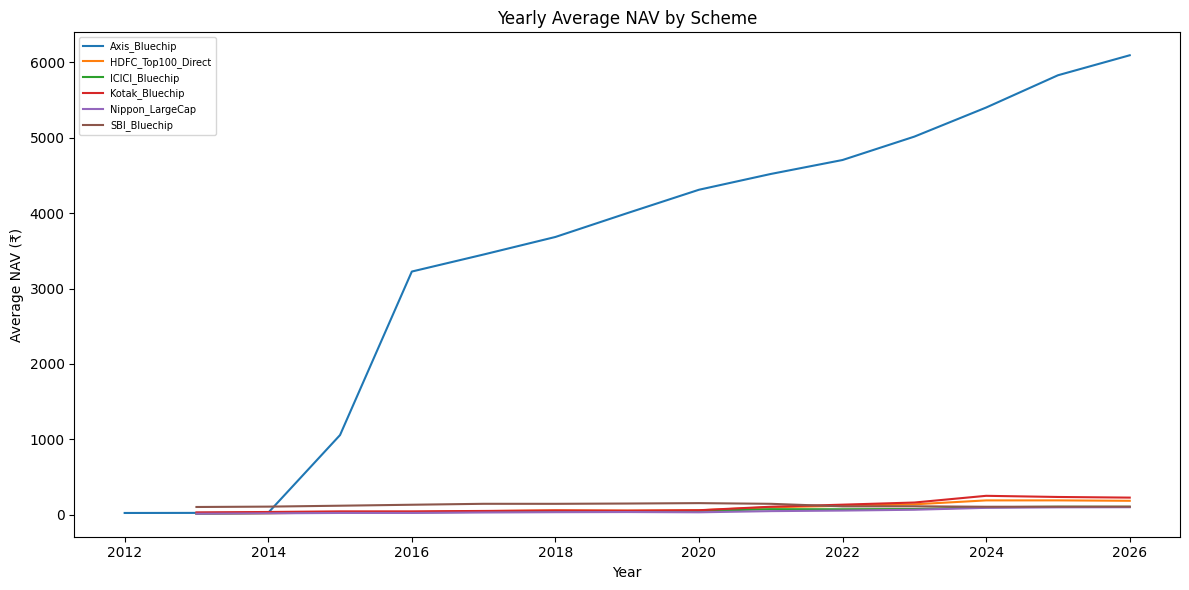

Chart 3 saved!


In [9]:
# Chart 3 - Year wise average NAV
all_data['year'] = all_data['date'].dt.year
yearly = all_data.groupby(['year','scheme_name'])['nav'].mean().unstack()

yearly.plot(figsize=(12,6))
plt.title('Yearly Average NAV by Scheme')
plt.xlabel('Year')
plt.ylabel('Average NAV (₹)')
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig(r"C:\Users\JATIN\mutual_fund_project\reports\chart3_yearly_nav.png")
plt.show()
print("Chart 3 saved!")

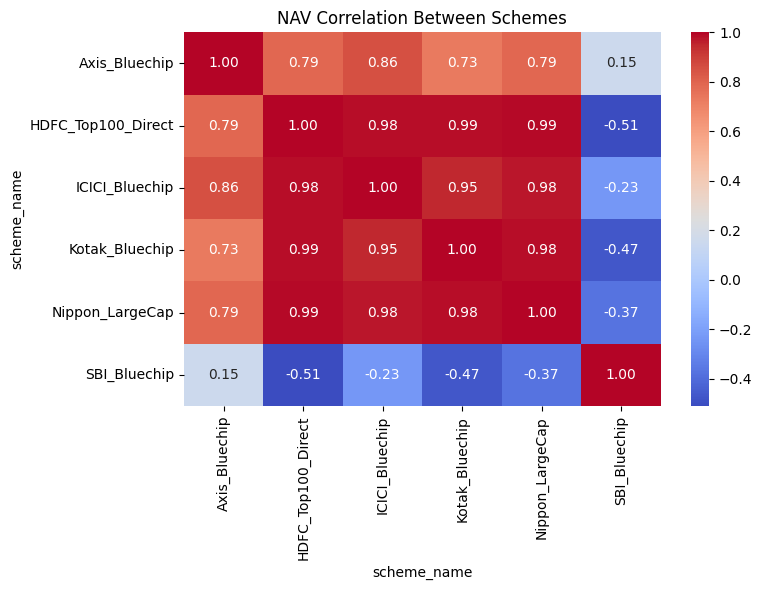

Chart 4 saved!


In [10]:
# Chart 4 - NAV Correlation Heatmap
pivot = all_data.pivot_table(index='date', columns='scheme_name', values='nav')
corr = pivot.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('NAV Correlation Between Schemes')
plt.tight_layout()
plt.savefig(r"C:\Users\JATIN\mutual_fund_project\reports\chart4_correlation.png")
plt.show()
print("Chart 4 saved!")

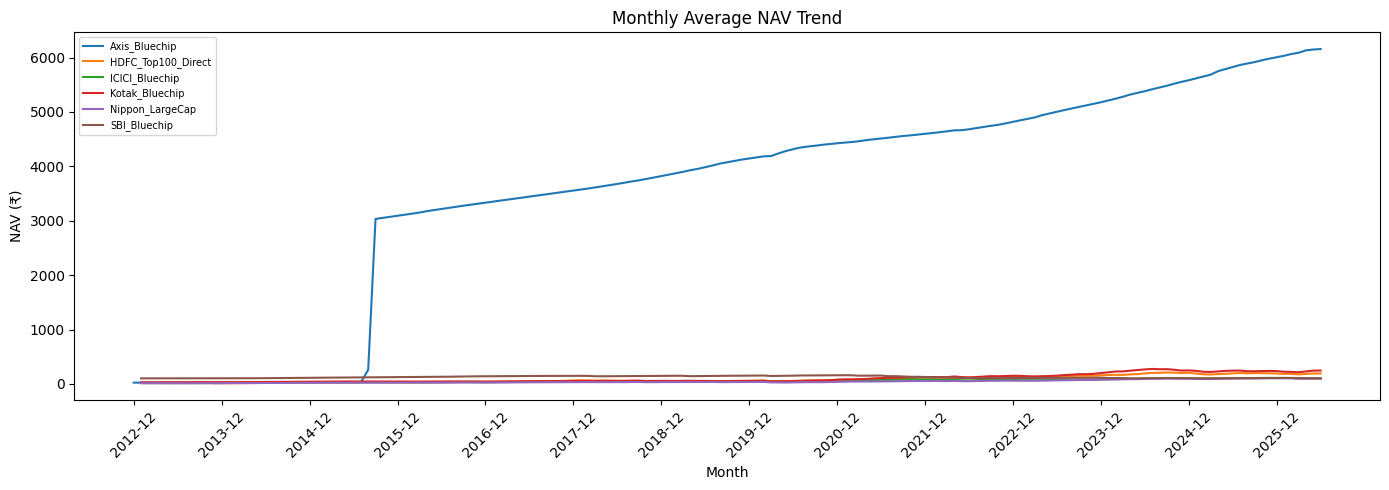

Chart 5 saved!


In [11]:
# Chart 5 - Monthly average NAV
all_data['month'] = all_data['date'].dt.to_period('M')
monthly = all_data.groupby(['month','scheme_name'])['nav'].mean().unstack()
monthly.index = monthly.index.astype(str)

plt.figure(figsize=(14,5))
for col in monthly.columns:
    plt.plot(monthly.index, monthly[col], label=col)
plt.title('Monthly Average NAV Trend')
plt.xlabel('Month')
plt.ylabel('NAV (₹)')
plt.xticks(monthly.index[::12], rotation=45)
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig(r"C:\Users\JATIN\mutual_fund_project\reports\chart5_monthly_nav.png")
plt.show()
print("Chart 5 saved!")

<Figure size 1000x600 with 0 Axes>

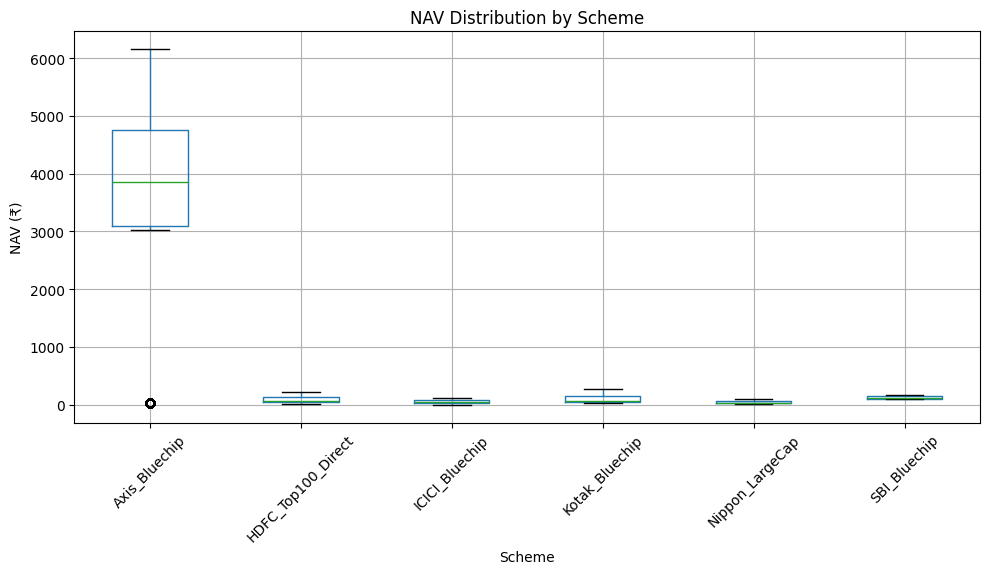

Chart 6 saved!


In [12]:
# Chart 6 - NAV Distribution Boxplot
plt.figure(figsize=(10,6))
all_data.boxplot(column='nav', by='scheme_name', figsize=(10,6))
plt.title('NAV Distribution by Scheme')
plt.suptitle('')
plt.xlabel('Scheme')
plt.ylabel('NAV (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r"C:\Users\JATIN\mutual_fund_project\reports\chart6_boxplot.png")
plt.show()
print("Chart 6 saved!")

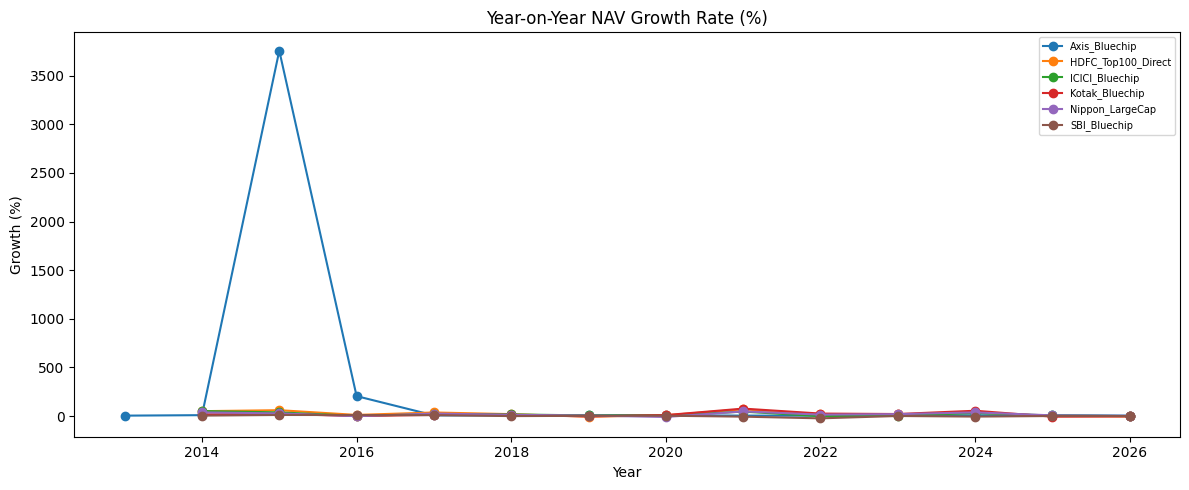

Chart 7 saved!


In [13]:
# Chart 7 - NAV Growth Rate Year on Year
all_data['year'] = all_data['date'].dt.year
yearly_avg = all_data.groupby(['year','scheme_name'])['nav'].mean().unstack()
growth = yearly_avg.pct_change() * 100

growth.plot(figsize=(12,5), marker='o')
plt.title('Year-on-Year NAV Growth Rate (%)')
plt.xlabel('Year')
plt.ylabel('Growth (%)')
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig(r"C:\Users\JATIN\mutual_fund_project\reports\chart7_growth_rate.png")
plt.show()
print("Chart 7 saved!")

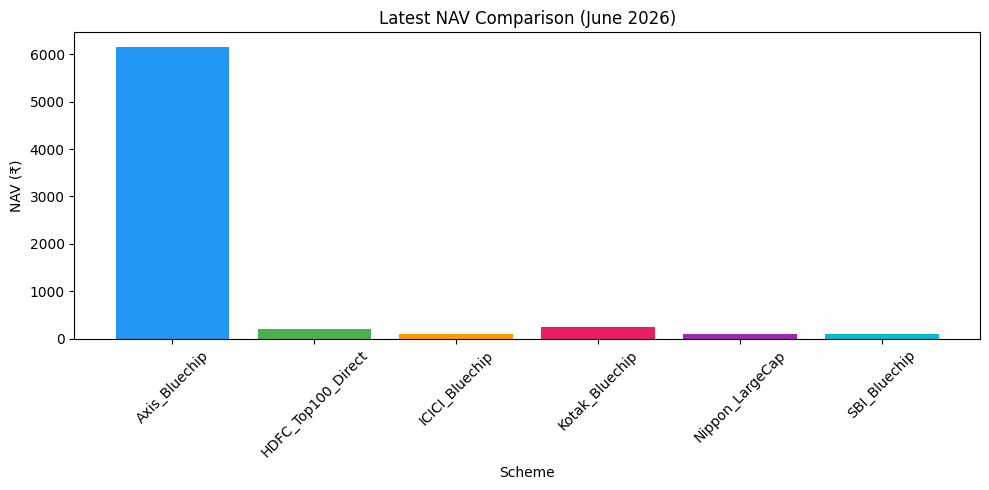

Chart 8 saved!


In [14]:
# Chart 8 - Latest NAV comparison
latest = all_data.sort_values('date').groupby('scheme_name').last().reset_index()

plt.figure(figsize=(10,5))
plt.bar(latest['scheme_name'], latest['nav'], color=['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4'])
plt.title('Latest NAV Comparison (June 2026)')
plt.xlabel('Scheme')
plt.ylabel('NAV (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r"C:\Users\JATIN\mutual_fund_project\reports\chart8_latest_nav.png")
plt.show()
print("Chart 8 saved!")

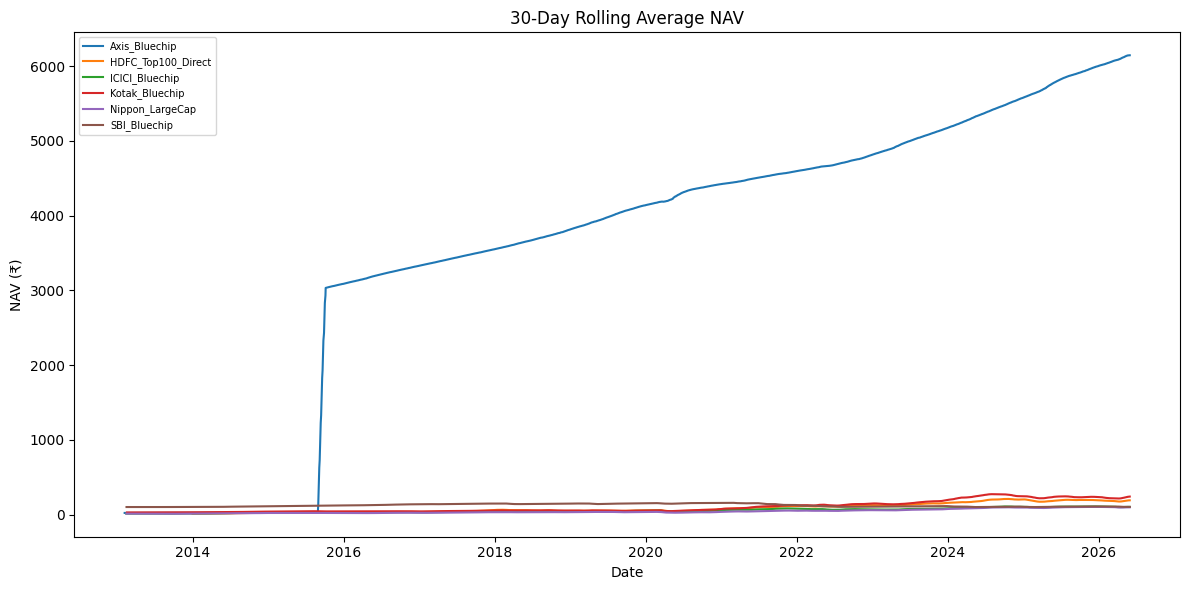

Chart 9 saved!


In [15]:
# Chart 9 - Rolling 30 day average NAV
plt.figure(figsize=(12,6))
for scheme in all_data['scheme_name'].unique():
    df = all_data[all_data['scheme_name']==scheme].sort_values('date')
    df['rolling'] = df['nav'].rolling(30).mean()
    plt.plot(df['date'], df['rolling'], label=scheme)

plt.title('30-Day Rolling Average NAV')
plt.xlabel('Date')
plt.ylabel('NAV (₹)')
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig(r"C:\Users\JATIN\mutual_fund_project\reports\chart9_rolling_avg.png")
plt.show()
print("Chart 9 saved!")

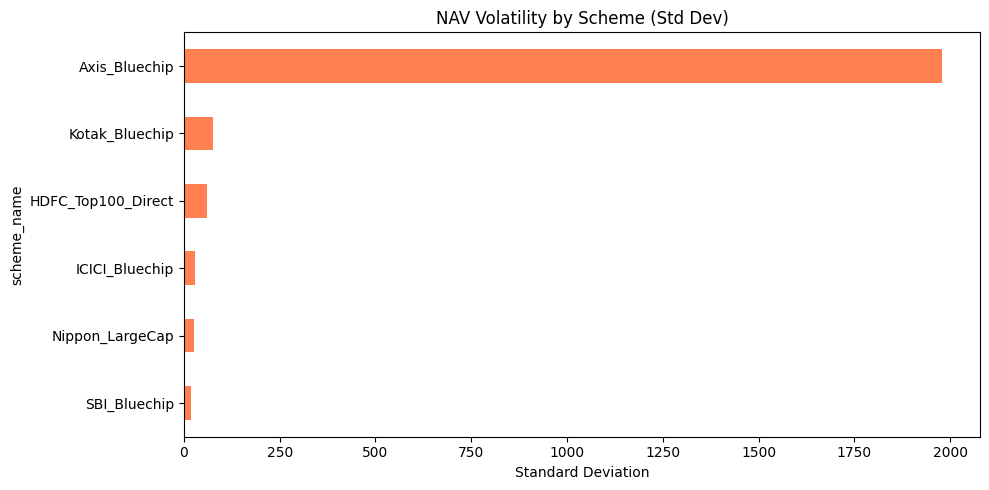

Chart 10 saved!


In [16]:
# Chart 10 - NAV Volatility (Standard Deviation)
volatility = all_data.groupby('scheme_name')['nav'].std().sort_values()

plt.figure(figsize=(10,5))
volatility.plot(kind='barh', color='coral')
plt.title('NAV Volatility by Scheme (Std Dev)')
plt.xlabel('Standard Deviation')
plt.tight_layout()
plt.savefig(r"C:\Users\JATIN\mutual_fund_project\reports\chart10_volatility.png")
plt.show()
print("Chart 10 saved!")